In [1]:
# import pytensor
# pytensor.config.cxx = "/usr/bin/clang++"

import pandas
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# import pymc as pm
# import arviz as az
# import pytensor.tensor as pt
# from scipy.special import expit

%matplotlib inline
%config InlineBackend.figure_format = "retina"

sns.set(rc={"figure.figsize" : (25, 15)})
sns.set(font_scale=2)
sns.set_style("ticks")

In [2]:
poll_df = pandas.read_csv(
    "https://docs.google.com/spreadsheets/d/1AZfxs2caMVdYPsiqiZJmX3P-CTq5Yewi3CAccvT7acw/export?format=csv",
    parse_dates=["end_date"])
poll_df = poll_df[poll_df["pollster"].notnull()].copy()
del poll_df["url"]
poll_df = poll_df[poll_df["partisan"] == "0"].copy() # TODO: also do partisan polls?
poll_df = poll_df[poll_df["kind"] == "horse"].copy() # TODO: also do favourability?

In [3]:
poll_df

,pollster,end_date,population,mode,sample_size,moe,credible_interval,kind,partisan,Baraka,Fulop,Gottheimer,Sherrill,Spiller,Sweeney,Undecided,Weight
23,Rutgers-Eagleton,2025-04-10,rv,phone/text-to-web/panel,966.0,4.3,NaN,horse,0,10.512304,11.621924,11.646532,16.243848,10.756152,6.621924,32.597315,1.0
24,AARP / Siena College,2025-05-01,rv,phone/text-to-web/panel,454.0,5.1,NaN,horse,0,11.000000,9.000000,9.000000,25.000000,7.000000,0.000000,32.000000,1.0
25,Insider NJ / StimSight Research,2025-05-10,lv,phone/text-to-web,409.0,4.9,NaN,horse,0,21.000000,19.000000,10.000000,31.000000,9.000000,9.000000,1.000000,1.0
26,Emerson College / PIX11 / The Hill,2025-05-13,rv,phone/text-to-web/panel,386.0,NaN,4.9,horse,0,11.000000,11.000000,11.000000,28.000000,10.000000,5.000000,24.000000,1.0


In [4]:
results = pandas.Series(
    {"Baraka" : 20.4, "Fulop" : 15.9, "Gottheimer" : 11.8, "Sherrill" : 34.0, "Spiller" : 10.7, "Sweeney" : 7.2})
results.name = "results"

In [5]:
results

Baraka        20.4
Fulop         15.9
Gottheimer    11.8
Sherrill      34.0
Spiller       10.7
Sweeney        7.2
Name: results, dtype: float64

In [6]:
poll_df = poll_df[["pollster"] + list(results.index)].melt(id_vars=["pollster"], var_name="Candidate")

In [7]:
poll_df = poll_df.merge(pandas.DataFrame(results), left_on=["Candidate"], right_index=True, how="left")

In [8]:
poll_df["diff"] = poll_df["results"] - poll_df["value"]

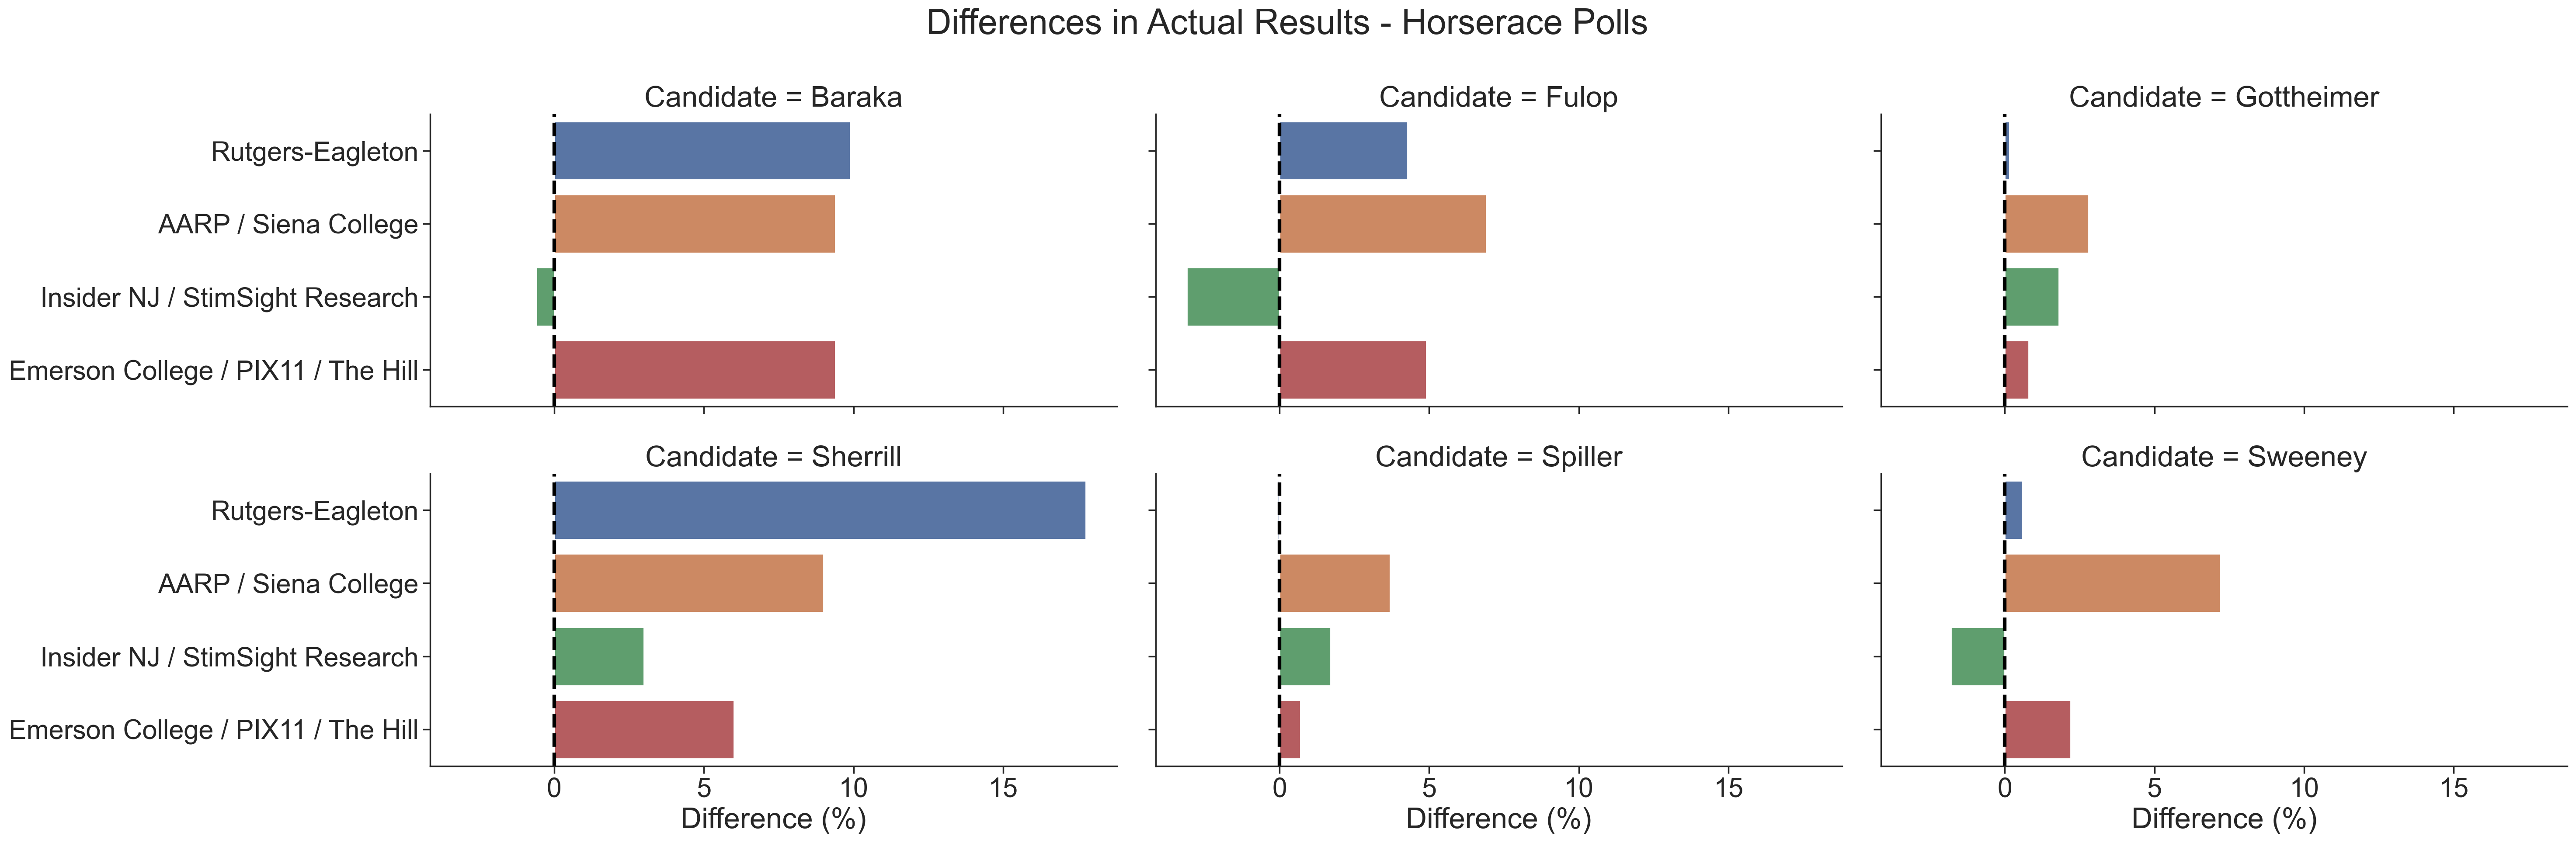

In [9]:
g = sns.catplot(data=poll_df, kind="bar", y="pollster", x="diff", col="Candidate", hue="pollster", col_wrap=3, aspect=2)
g.set_ylabels("")
g.set_xlabels("Difference (%)")
for ax in g.axes.flat:
    ax.axvline(x=0, color="black", linestyle="--", linewidth=3)
g.fig.suptitle("Differences in Actual Results - Horserace Polls")
plt.tight_layout()

In [15]:
poll_df_100 = poll_df.copy()
poll_df_100 = poll_df_100.merge(poll_df_100.groupby(["pollster"]).agg(total = pandas.NamedAgg("value", "sum")).reset_index(),
                                on=["pollster"], how="left")
poll_df_100["value"] = (poll_df_100["value"] / poll_df_100["total"]) * 100

In [17]:
poll_df_100["diff"] = poll_df_100["results"] - poll_df_100["value"]

In [18]:
del poll_df_100["total"]

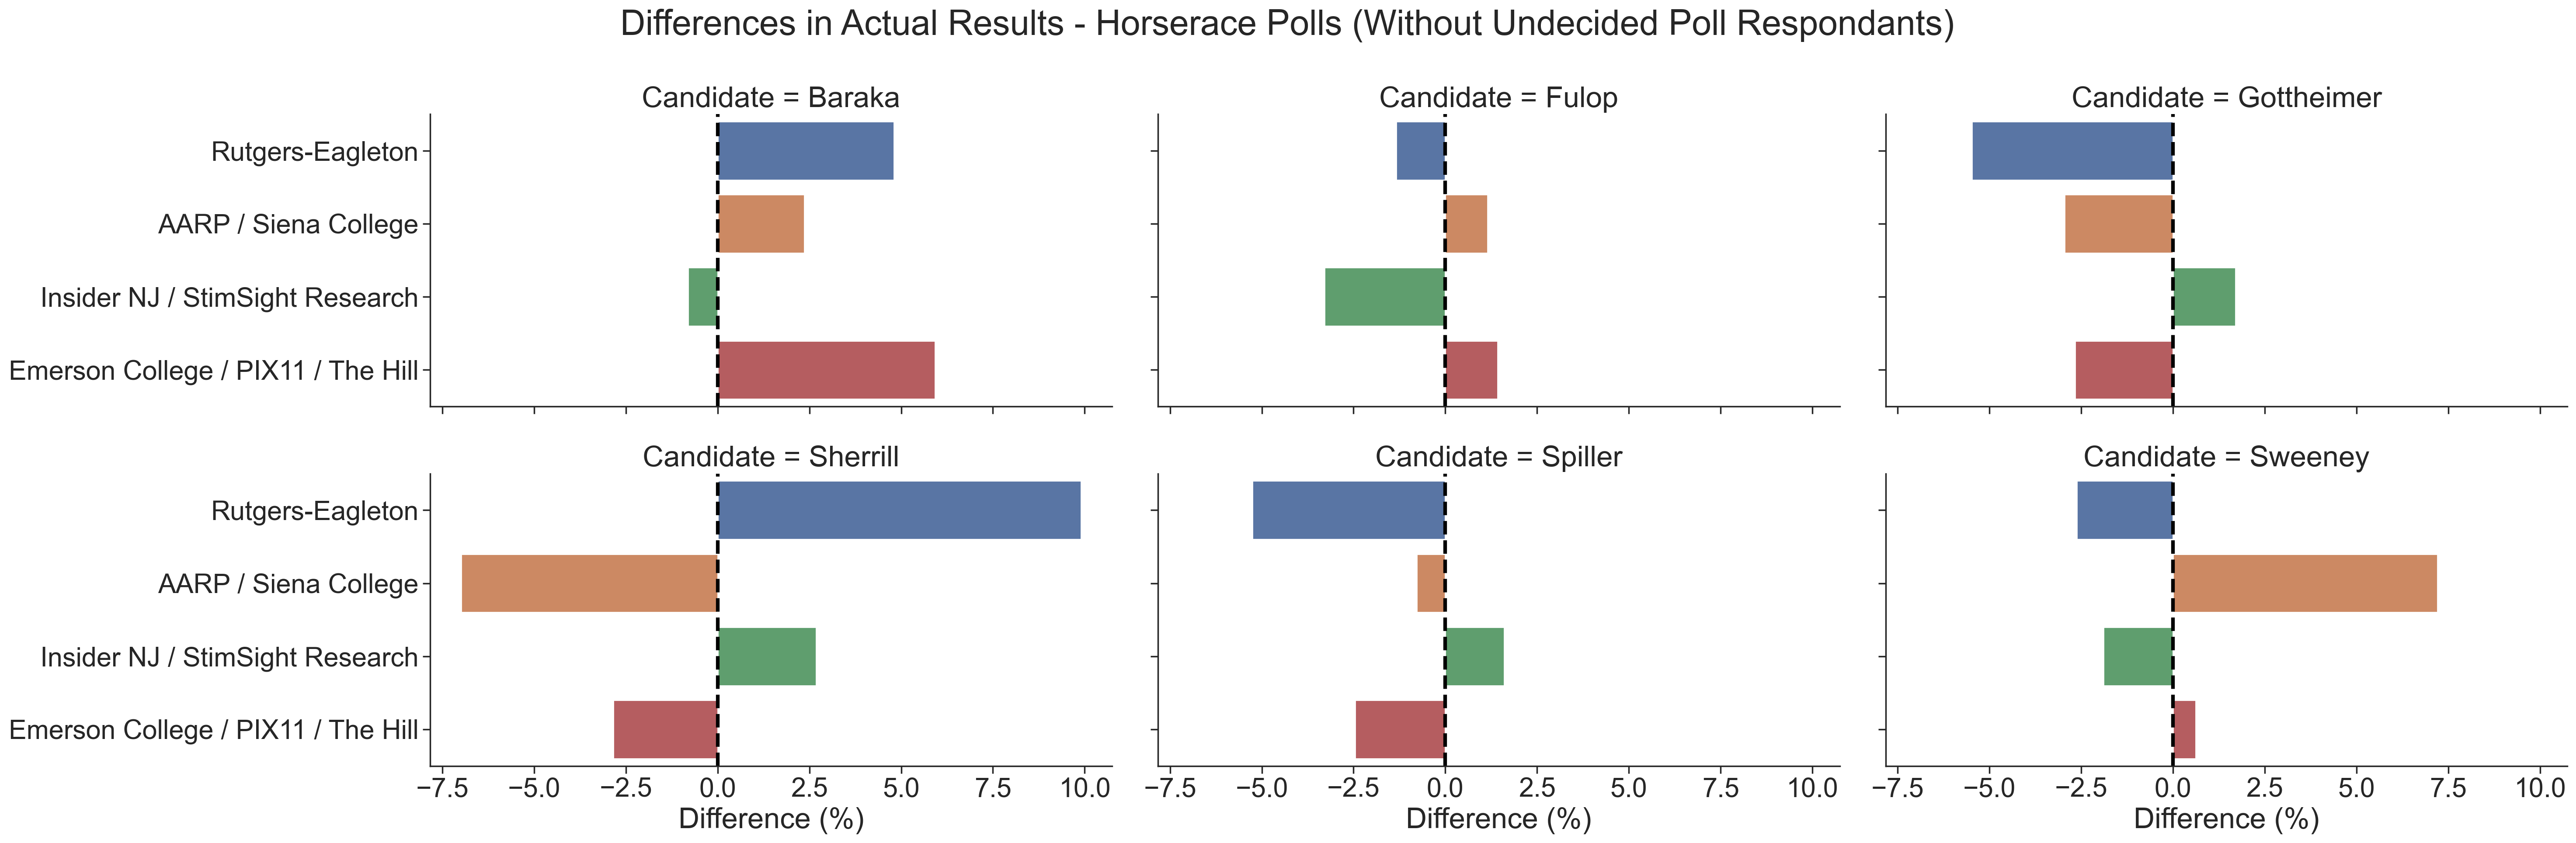

In [19]:
g = sns.catplot(data=poll_df_100, kind="bar", y="pollster", x="diff", col="Candidate", hue="pollster", col_wrap=3, aspect=2)
g.set_ylabels("")
g.set_xlabels("Difference (%)")
for ax in g.axes.flat:
    ax.axvline(x=0, color="black", linestyle="--", linewidth=3)
g.fig.suptitle("Differences in Actual Results - Horserace Polls (Without Undecided Poll Respondants)")
plt.tight_layout()

In [21]:
poll_df_100.groupby(["Candidate"]).agg({"diff" : "mean"})

,diff
Candidate,
Baraka,3.071285
Fulop,-0.515556
Gottheimer,-2.351957
Sherrill,0.690363
Spiller,-1.720565
Sweeney,0.826430
